In [1]:
import pandas as pd

# Load the uploaded Excel file to check its structure
file_path = '../dataset/rab94row.xlsx'
data = pd.read_excel(file_path)

# Display the first few rows to understand the structure
data.head()

,namaproyek,rab,waktu,provinsi,tahun,luas,subitem,tinggi,lantai,ikk,ihbp,inflasi
0,Gedung Apartemen,871000000000,606,DKI Jakarta,2021,68204.25309,6,120.020872,31,121.42,109.64,1.53
1,Gedung Apartemen,876000000000,605,DKI Jakarta,2021,68590.48909,6,120.617753,31,121.42,109.64,1.53
2,Gedung Apartemen,936000000000,649,DKI Jakarta,2020,73232.95902,6,128.564830,33,116.84,103.68,1.59
3,Gedung Apartemen,938000000000,628,DKI Jakarta,2020,73318.17099,6,128.882451,33,116.84,103.68,1.59
4,Gedung Apartemen,1050000000000,668,DKI Jakarta,2020,81640.56895,6,142.594757,36,116.84,103.68,1.59


In [2]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 94 entries, 0 to 93
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   namaproyek  94 non-null     object 
 1   rab         94 non-null     int64  
 2   waktu       94 non-null     int64  
 3   provinsi    94 non-null     object 
 4   tahun       94 non-null     int64  
 5   luas        94 non-null     float64
 6   subitem     94 non-null     int64  
 7   tinggi      94 non-null     float64
 8   lantai      94 non-null     int64  
 9   ikk         94 non-null     float64
 10  ihbp        94 non-null     float64
 11  inflasi     94 non-null     float64
dtypes: float64(5), int64(5), object(2)
memory usage: 8.9+ KB


In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import AdaBoostRegressor, GradientBoostingRegressor, RandomForestRegressor
from sklearn.linear_model import BayesianRidge, Lasso, LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
import xgboost as xgb
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

In [4]:
# Label encoding kolom 'Provinsi' dan nama proyek karena nilainya kategorikal
label_encoder = LabelEncoder()
data['label_provinsi'] = label_encoder.fit_transform(data['provinsi'])
data['label_namaproyek'] = label_encoder.fit_transform(data['namaproyek'])

# Melihat nilai unik dari hasil encoding kolom 'provinsi_encoded'
provinsi_unik = data[['provinsi', 'label_provinsi']].drop_duplicates().sort_values(
    by='label_provinsi')

# Melihat nilai unik dari hasil encoding kolom 'namaproyek_encoded'
namaproyek_unik = data[['namaproyek', 'label_namaproyek']].drop_duplicates().sort_values(
    by='label_namaproyek')

In [5]:
provinsi_unik

,provinsi,label_provinsi
90,Bali,0
77,Banten,1
0,DKI Jakarta,2
39,Jawa Barat,3
68,Jawa Timur,4
85,Kalimantan Timur,5
87,Sulawesi Selatan,6


In [6]:
namaproyek_unik

,namaproyek,label_namaproyek
0,Gedung Apartemen,0


In [7]:
data.corr(numeric_only=True)

,rab,waktu,tahun,luas,subitem,tinggi,lantai,ikk,ihbp,inflasi,label_provinsi,label_namaproyek
rab,1.000000,0.982262,-0.090441,0.999900,0.328408,0.996631,0.996013,0.041004,0.056369,0.055564,-0.034124,NaN
waktu,0.982262,1.000000,-0.115240,0.982144,0.263061,0.986283,0.982037,0.037824,0.087599,0.063666,-0.029806,NaN
tahun,-0.090441,-0.115240,1.000000,-0.090192,0.001342,-0.095553,-0.084871,-0.139272,-0.521197,0.083498,0.121568,NaN
luas,0.999900,0.982144,-0.090192,1.000000,0.327254,0.996939,0.996022,0.042075,0.055080,0.052929,-0.036005,NaN
subitem,0.328408,0.263061,0.001342,0.327254,1.000000,0.279291,0.277861,-0.135471,-0.068469,-0.084792,-0.134421,NaN
tinggi,0.996631,0.986283,-0.095553,0.996939,0.279291,1.000000,0.997575,0.062180,0.061185,0.050301,-0.035330,NaN
lantai,0.996013,0.982037,-0.084871,0.996022,0.277861,0.997575,1.000000,0.064248,0.049017,0.045683,-0.030228,NaN
ikk,0.041004,0.037824,-0.139272,0.042075,-0.135471,0.062180,0.064248,1.000000,0.077721,-0.127792,-0.298932,NaN
ihbp,0.056369,0.087599,-0.521197,0.055080,-0.068469,0.061185,0.049017,0.077721,1.000000,0.307840,0.057543,NaN
inflasi,0.055564,0.063666,0.083498,0.052929,-0.084792,0.050301,0.045683,-0.127792,0.307840,1.000000,0.493391,NaN


In [8]:
# Split data into features and target
X1 = data.drop(columns=['rab', 'namaproyek', 'provinsi'])
y1 = data['rab']

# Split into training and testing sets
X_train1, X_test1, y_train1, y_test1 = train_test_split(
    X1, y1, 
    test_size=0.3, 
    random_state=42)

# Split into training and testing sets
X_train2, X_test2, y_train2, y_test2 = train_test_split(
    X1, y1, 
    test_size=0.2, 
    random_state=42)



In [9]:
# Initialize models
models1 = {
    'AdaBoost': AdaBoostRegressor(random_state=42),
    'Bayesian Ridge': BayesianRidge(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'KNN Regressor': KNeighborsRegressor(),
    'Lasso Regression': Lasso(random_state=42),
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Ridge Regression': Ridge(random_state=42),
    'SVR': SVR(),
    'XGBoost': xgb.XGBRegressor(random_state=42)
}

models2 = {
    'AdaBoost': AdaBoostRegressor(random_state=42),
    'Bayesian Ridge': BayesianRidge(),
    'Decision Tree': DecisionTreeRegressor(random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(random_state=42),
    'KNN Regressor': KNeighborsRegressor(),
    'Lasso Regression': Lasso(random_state=42),
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(random_state=42),
    'Ridge Regression': Ridge(random_state=42),
    'SVR': SVR(),
    'XGBoost': xgb.XGBRegressor(random_state=42)
}

# 70:30
# Train and evaluate each model with additional metrics
results1 = []
for name1, model1 in models1.items():
    # Fit model to training data
    model1.fit(X_train1, y_train1)
    
    # Predict on training data
    y_train_pred1 = model1.predict(X_train1)
    
    # Predict on testing data
    y_pred1 = model1.predict(X_test1)
    
    # Calculate metrics for training data
    r2_train1 = r2_score(y_train1, y_train_pred1)
    
    # Calculate metrics for testing data
    mse1 = mean_squared_error(y_test1, y_pred1)
    mae1 = mean_absolute_error(y_test1, y_pred1)
    r21 = r2_score(y_test1, y_pred1)
    
    # Append results
    results1.append({
        'Model': name1,
        'Training R2 Score': r2_train1,
        'Testing RMSE': np.sqrt(mse1),
        'Testing MAE': mae1,
        'Testing R2 Score': r21
    })

# Convert results into a DataFrame for better visualization
results_df1 = pd.DataFrame(results1).sort_values(by='Testing R2 Score', ascending=False)

# 80:20
# Train and evaluate each model with additional metrics
results2 = []
for name2, model2 in models2.items():
    # Fit model to training data
    model2.fit(X_train2, y_train2)
    
    # Predict on training data
    y_train_pred2 = model2.predict(X_train2)
    
    # Predict on testing data
    y_pred2 = model2.predict(X_test2)
    
    # Calculate metrics for training data
    r2_train2 = r2_score(y_train2, y_train_pred2)
    
    # Calculate metrics for testing data
    mse2 = mean_squared_error(y_test2, y_pred2)
    mae2 = mean_absolute_error(y_test2, y_pred2)
    r22 = r2_score(y_test2, y_pred2)
    
    # Append results
    results2.append({
        'Model': name2,
        'Training R2 Score': r2_train2,
        'Testing RMSE': np.sqrt(mse2),
        'Testing MAE': mae2,
        'Testing R2 Score': r22
    })

# Convert results into a DataFrame for better visualization
results_df2 = pd.DataFrame(results2).sort_values(by='Testing R2 Score', ascending=False)


Hasil 70:30

In [10]:
results_df1

,Model,Training R2 Score,Testing RMSE,Testing MAE,Testing R2 Score
6,Linear Regression,9.998225e-01,2.009386e+09,1.332518e+09,0.999852
5,Lasso Regression,9.998224e-01,2.014488e+09,1.325060e+09,0.999851
8,Ridge Regression,9.998209e-01,2.040590e+09,1.304769e+09,0.999848
7,Random Forest,9.983322e-01,1.388292e+10,6.804138e+09,0.992945
4,KNN Regressor,9.756463e-01,1.625962e+10,7.489655e+09,0.990323
3,Gradient Boosting,9.999999e-01,2.045756e+10,8.580848e+09,0.984681
0,AdaBoost,9.973788e-01,2.056556e+10,1.035378e+10,0.984519
2,Decision Tree,1.000000e+00,2.270197e+10,1.006897e+10,0.981136
10,XGBoost,1.000000e+00,3.421979e+10,1.416440e+10,0.957138
1,Bayesian Ridge,7.280843e-13,1.663792e+11,1.362345e+11,-0.013236


Hasil 80:20

In [11]:
results_df2

,Model,Training R2 Score,Testing RMSE,Testing MAE,Testing R2 Score
6,Linear Regression,9.998264e-01,1.726102e+09,1.162028e+09,0.999876
5,Lasso Regression,9.998263e-01,1.733451e+09,1.159370e+09,0.999875
8,Ridge Regression,9.998248e-01,1.756136e+09,1.152386e+09,0.999872
4,KNN Regressor,9.899213e-01,1.739171e+10,7.284211e+09,0.987438
7,Random Forest,9.980479e-01,1.932923e+10,9.583684e+09,0.984483
3,Gradient Boosting,9.999999e-01,2.499717e+10,9.141714e+09,0.974048
0,AdaBoost,9.960120e-01,2.522887e+10,1.493393e+10,0.973565
10,XGBoost,1.000000e+00,2.615567e+10,1.188536e+10,0.971587
2,Decision Tree,1.000000e+00,3.531587e+10,1.184211e+10,0.948200
9,SVR,-2.023078e-01,1.569663e+11,1.063158e+11,-0.023297


Cek Distribusinya

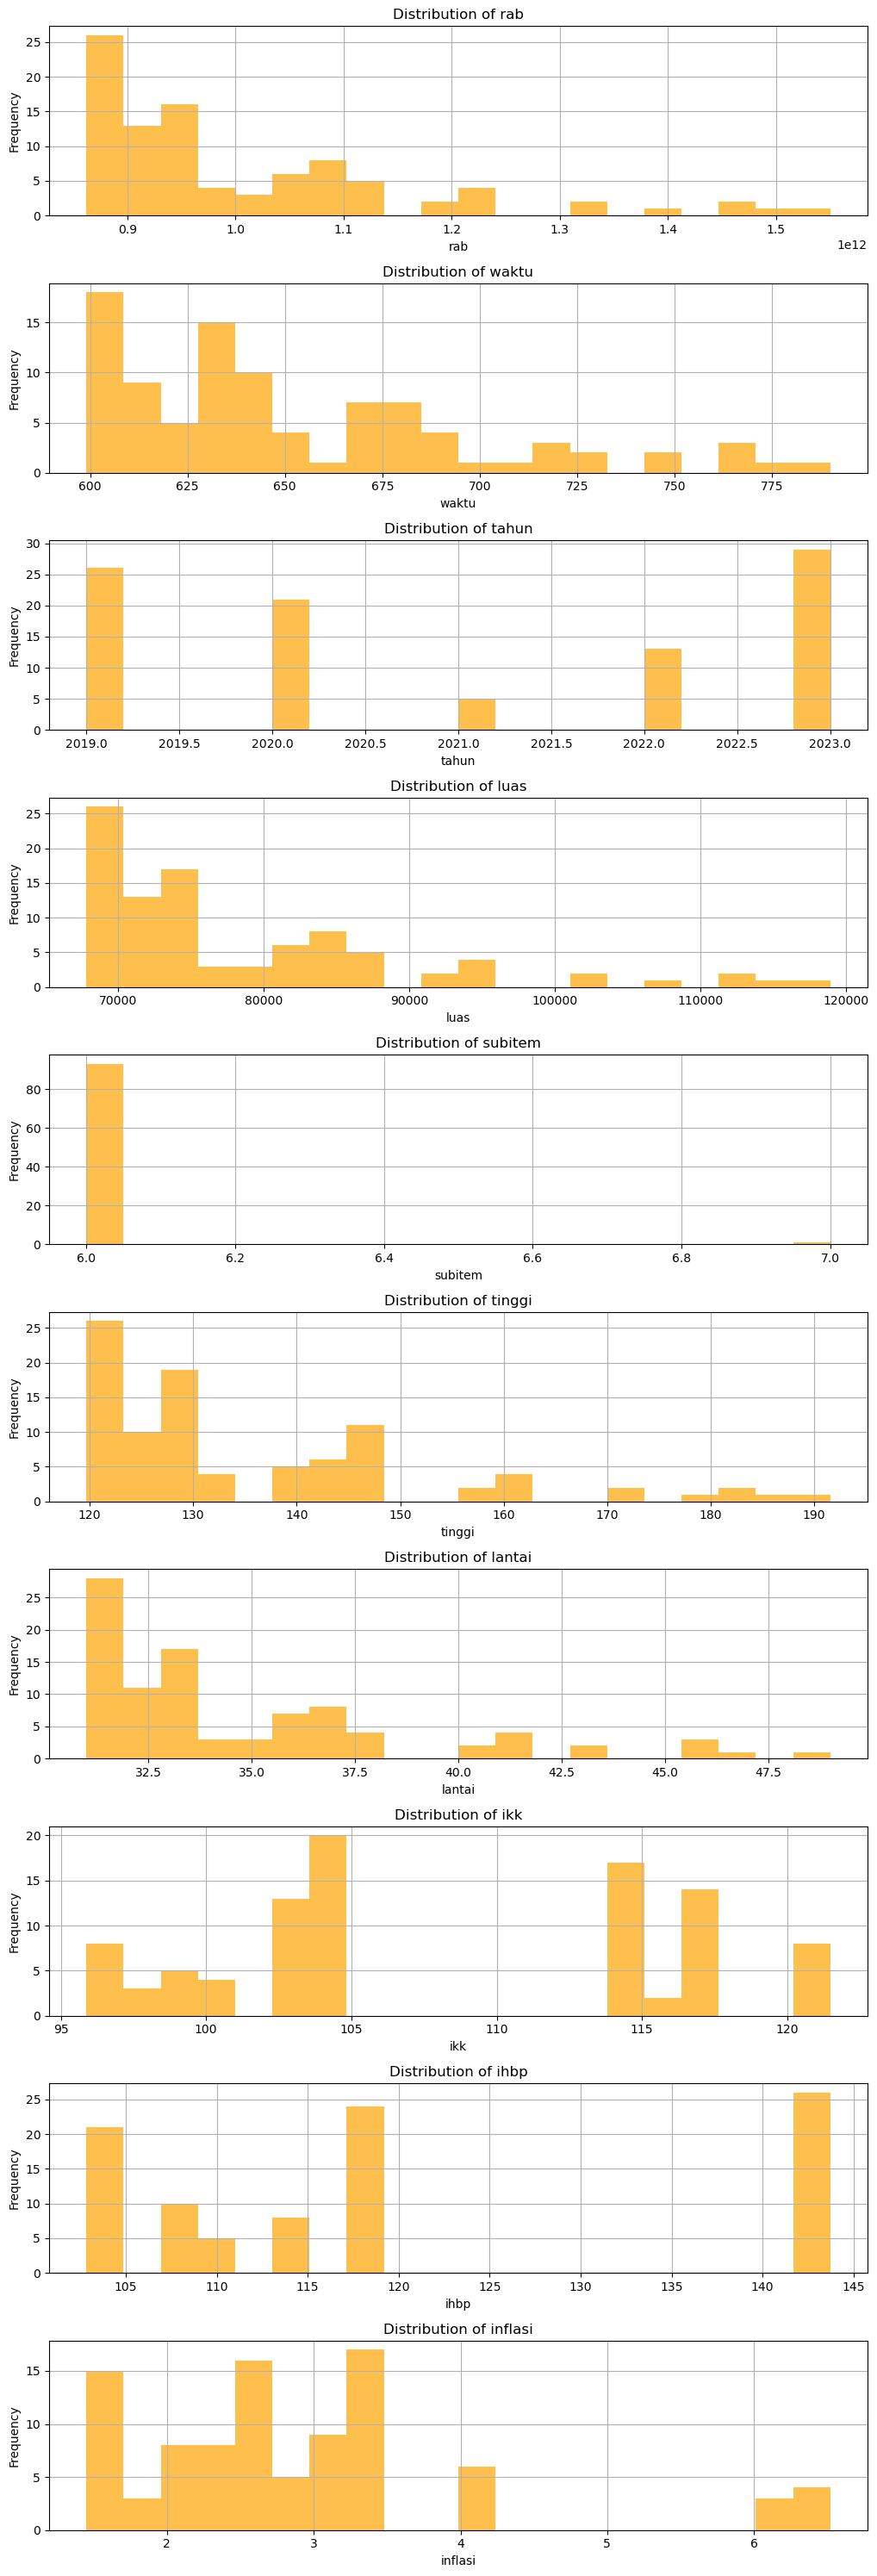

In [12]:
# Compare distributions before and after transformation using histograms
import matplotlib.pyplot as plt

numerical_columns = ['rab', 'waktu', 'tahun', 'luas', 'subitem', 
                     'tinggi', 'lantai', 'ikk', 'ihbp', 'inflasi']

plt.figure(figsize=(20, 30))
for i, col in enumerate(numerical_columns, 1):

    # Transformed data
    plt.subplot(len(numerical_columns), 2, 2 * i)
    data[col].hist(bins=20, alpha=0.7, color='orange')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

Cek Korelasinya

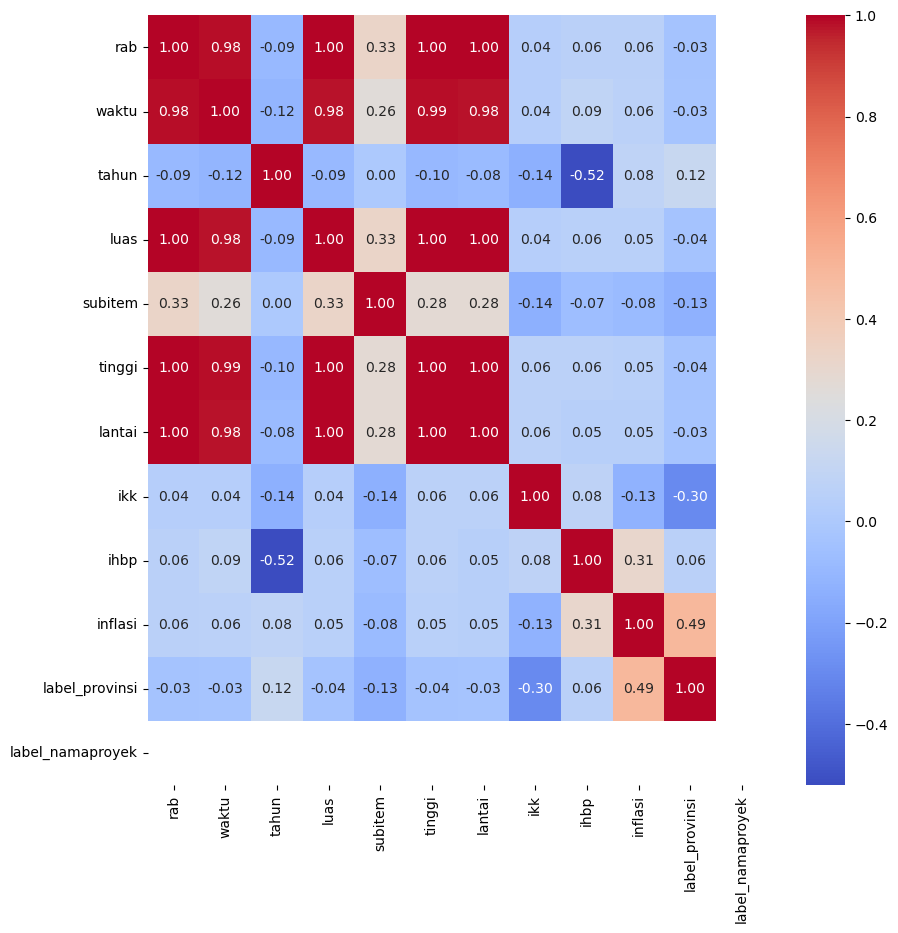

In [13]:
# Digunakan untuk membuat visualisasi dalam bentuk grafik atau plot
import seaborn as sns
import matplotlib.pyplot as plt
# Visualisasi korelasi antar fitur atau kolom apakah saling berpengaruh atau tidak
fig, ax = plt.subplots(figsize=(10,10))  
sns.heatmap(data.corr(numeric_only=True), 
            annot=True, cmap='coolwarm', fmt='.2f', ax=ax)
plt.show()

In [14]:
# Ambil model terbaik dari split data 70:30
best_model_name1 = results_df1.iloc[0]['Model']
best_model1 = models1[best_model_name1]

# Ambil model terbaik dari split data 80:20
best_model_name2 = results_df2.iloc[0]['Model']
best_model2 = models2[best_model_name2]

In [15]:
# Prediksi nilai actual dan prediksi untuk 70:30
y_actual1 = y_test1
y_pred_best1 = best_model1.predict(X_test1)

# Prediksi nilai actual dan prediksi untuk 80:20
y_actual2 = y_test2
y_pred_best2 = best_model2.predict(X_test2)


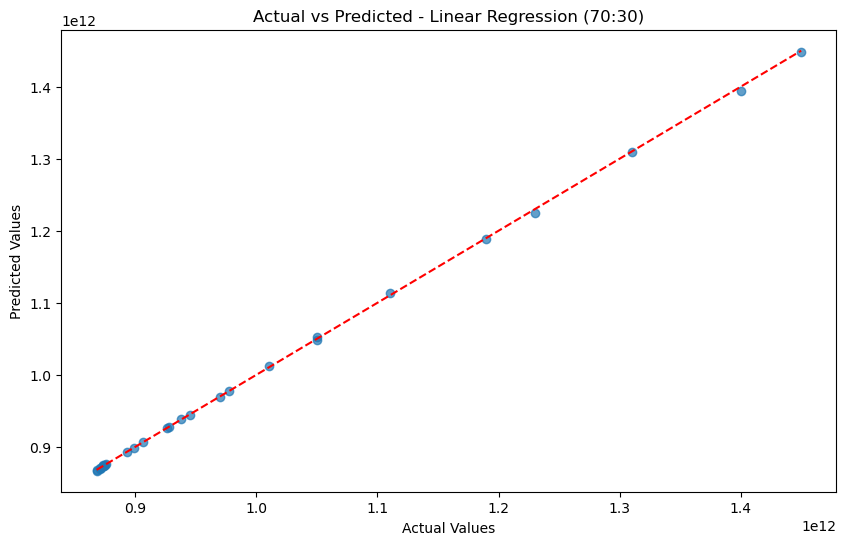

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_actual1, y_pred_best1, alpha=0.7)
plt.plot([y_actual1.min(), y_actual1.max()], [y_actual1.min(), y_actual1.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Actual vs Predicted - {best_model_name1} (70:30)")
plt.show()


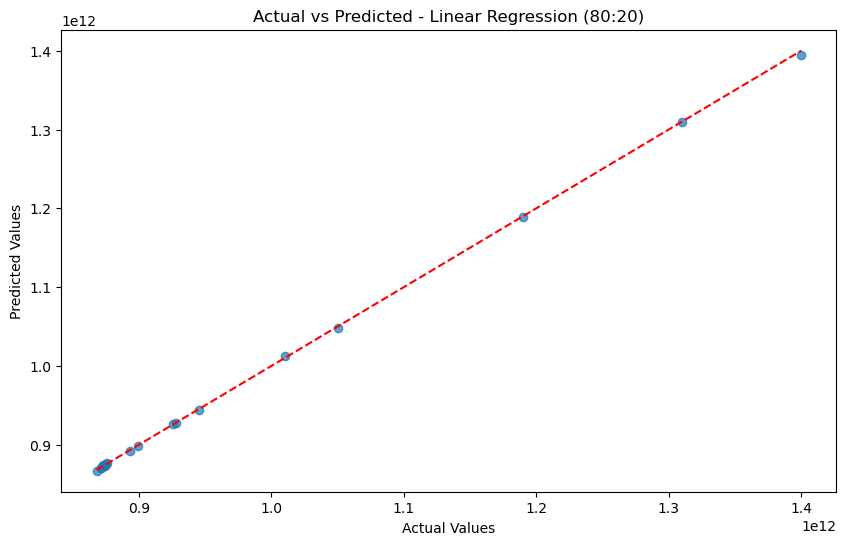

In [17]:
plt.figure(figsize=(10, 6))
plt.scatter(y_actual2, y_pred_best2, alpha=0.7)
plt.plot([y_actual2.min(), y_actual2.max()], [y_actual2.min(), y_actual2.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title(f"Actual vs Predicted - {best_model_name2} (80:20)")
plt.show()


In [18]:
# Dataframe untuk 70:30
comparison1 = pd.DataFrame({'Actual': y_actual1, 'Predicted': y_pred_best1})

# Dataframe untuk 80:20
comparison2 = pd.DataFrame({'Actual': y_actual2, 'Predicted': y_pred_best2})

# Tampilkan beberapa baris pertama
print(comparison1.head())
print(comparison2.head())


           Actual     Predicted
40   873000000000  8.726311e+11
22   928000000000  9.277926e+11
55  1400000000000  1.393481e+12
72   873000000000  8.727249e+11
0    871000000000  8.697456e+11
           Actual     Predicted
40   873000000000  8.724035e+11
22   928000000000  9.279382e+11
55  1400000000000  1.393964e+12
72   873000000000  8.724484e+11
0    871000000000  8.699450e+11


In [19]:
# Kembalikan nilai log ke bentuk asli
comparison1['Actual (Original)'] = comparison1['Actual']
comparison1['Predicted (Original)'] = comparison1['Predicted']

comparison2['Actual (Original)'] = comparison2['Actual']
comparison2['Predicted (Original)'] = comparison2['Predicted']

# Format ke dalam Rupiah
def format_rupiah(value):
    return f"Rp {value:,.0f}".replace(",", ".")

comparison1['Actual (Rupiah)'] = comparison1['Actual (Original)'].apply(format_rupiah)
comparison1['Predicted (Rupiah)'] = comparison1['Predicted (Original)'].apply(format_rupiah)

comparison2['Actual (Rupiah)'] = comparison2['Actual (Original)'].apply(format_rupiah)
comparison2['Predicted (Rupiah)'] = comparison2['Predicted (Original)'].apply(format_rupiah)

# Tampilkan beberapa baris pertama
print(comparison1[['Actual (Rupiah)', 'Predicted (Rupiah)']])
print()
print("*" * 100)
print(comparison2[['Actual (Rupiah)', 'Predicted (Rupiah)']])


         Actual (Rupiah)    Predicted (Rupiah)
40    Rp 873.000.000.000    Rp 872.631.093.856
22    Rp 928.000.000.000    Rp 927.792.574.998
55  Rp 1.400.000.000.000  Rp 1.393.480.853.847
72    Rp 873.000.000.000    Rp 872.724.853.524
0     Rp 871.000.000.000    Rp 869.745.607.456
26  Rp 1.190.000.000.000  Rp 1.188.179.705.141
39    Rp 945.000.000.000    Rp 943.845.417.557
67    Rp 875.000.000.000    Rp 875.216.379.612
10    Rp 868.000.000.000    Rp 866.744.379.272
44    Rp 871.000.000.000    Rp 871.148.043.189
83    Rp 899.000.000.000    Rp 898.423.043.707
35    Rp 876.000.000.000    Rp 876.523.645.654
90  Rp 1.310.000.000.000  Rp 1.309.632.131.448
62    Rp 926.000.000.000    Rp 926.752.391.538
12    Rp 874.000.000.000    Rp 872.722.478.794
4   Rp 1.050.000.000.000  Rp 1.047.906.888.885
18    Rp 893.000.000.000    Rp 892.080.140.143
28  Rp 1.010.000.000.000  Rp 1.011.655.302.268
49    Rp 873.000.000.000    Rp 874.280.052.606
65    Rp 977.000.000.000    Rp 977.699.168.995
15    Rp 872.

Model 70:30

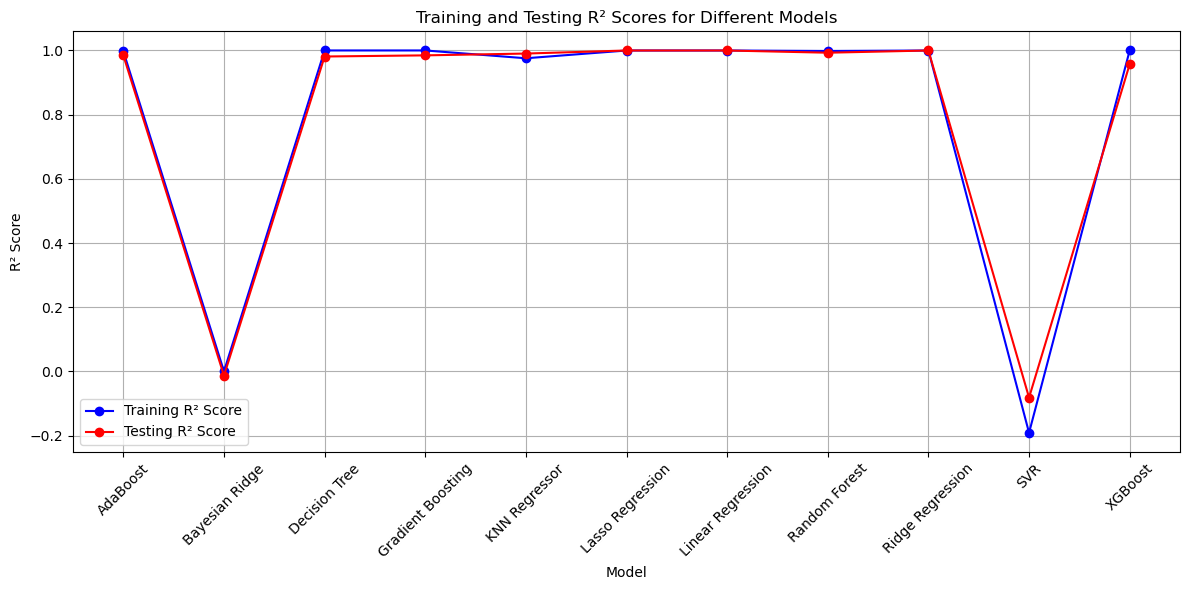

In [20]:
import matplotlib.pyplot as plt

# Extract model names and their corresponding R² scores
model_names = [r['Model'] for r in results1]
train_r2_scores = [r['Training R2 Score'] for r in results1]
test_r2_scores = [r['Testing R2 Score'] for r in results1]


# Set the figure size
plt.figure(figsize=(12, 6))

# Plot Training R² Scores
plt.plot(model_names, train_r2_scores, 'bo-', label='Training R² Score')

# Plot Testing R² Scores
plt.plot(model_names, test_r2_scores, 'ro-', label='Testing R² Score')

# Customize the plot
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.title('Training and Testing R² Scores for Different Models')
plt.xticks(rotation=45)  # Rotate model names for better visibility
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


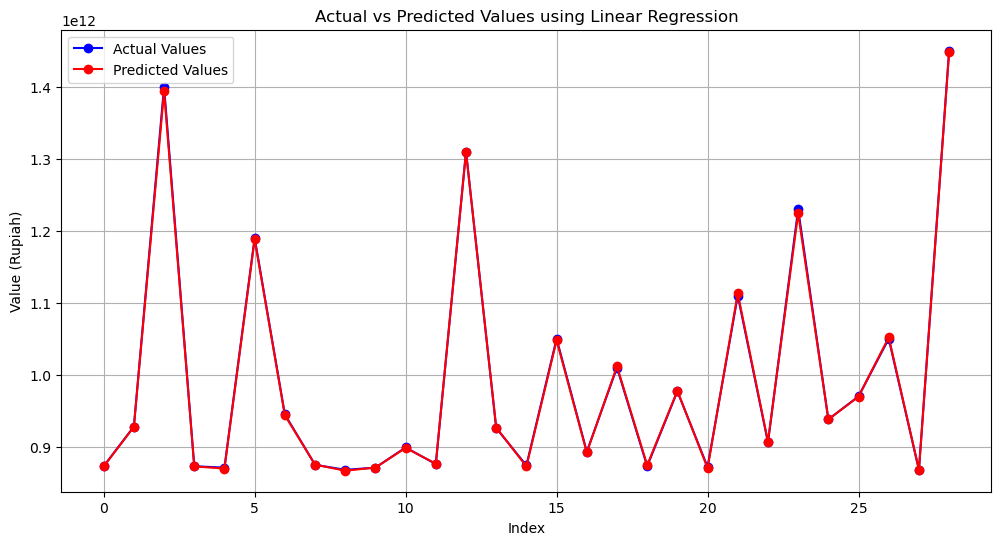

In [22]:
# Identify the best model based on Testing R² Score
best_model_name = results_df1.iloc[0]['Model']
best_model = models1[best_model_name]

# Predict on the test data
y_pred_log = best_model.predict(X_test1)

y_actual = y_test1.reset_index(drop=True)
y_pred = y_pred_log

# Create a DataFrame for comparison
comparison_df = pd.DataFrame({
    'Actual': y_actual,
    'Predicted': y_pred
})

# Plot Actual vs Predicted Values
plt.figure(figsize=(12, 6))
plt.plot(comparison_df.index, comparison_df['Actual'], 'bo-', label='Actual Values')
plt.plot(comparison_df.index, comparison_df['Predicted'], 'ro-', label='Predicted Values')
plt.xlabel('Index')
plt.ylabel('Value (Rupiah)')
plt.title(f'Actual vs Predicted Values using {best_model_name}')
plt.legend()
plt.grid(True)
plt.show()


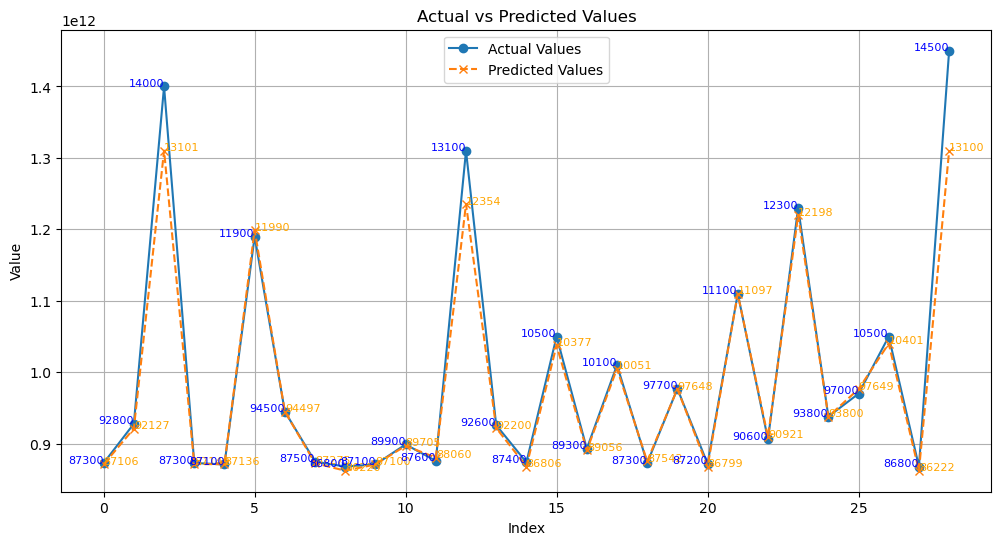

In [27]:
import matplotlib.pyplot as plt
import numpy as np


# Buat plot
plt.figure(figsize=(12, 6))
plt.plot(range(len(y_test1)), y_test1, label='Actual Values', marker='o', linestyle='-')
plt.plot(range(len(y_pred1)), y_pred1, label='Predicted Values', marker='x', linestyle='--')

# Tambahkan angka di setiap titik
for i, (y_actual, y_predict) in enumerate(zip(y_test1, y_pred1)):
    y_actual_str = f'{y_actual:.10f}'[:5]  # Ambil 5 karakter pertama
    y_predict_str = f'{y_predict:.10f}'[:5]  # Ambil 5 karakter pertama
    plt.text(i, y_actual, y_actual_str, fontsize=8, ha='right', color='blue')
    plt.text(i, y_predict, y_predict_str, fontsize=8, ha='left', color='orange')

# Tambahkan label dan judul
plt.xlabel('Index')
plt.ylabel('Value')
plt.title('Actual vs Predicted Values')
plt.legend()
plt.grid(True)

# Tampilkan plot
plt.show()

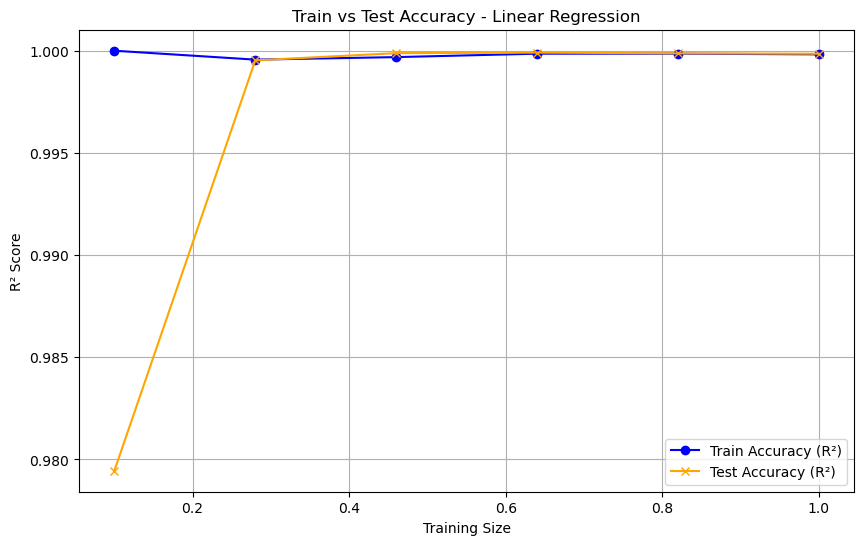

In [28]:
import numpy as np
import matplotlib.pyplot as plt

# Model terbaik dari results_df1
best_model_name = results_df1.iloc[0]['Model']
best_model = models1[best_model_name]

# Training sizes (misalnya dalam persen data training)
training_sizes = np.linspace(0.1, 1.0, 6)

# Menyimpan nilai R² untuk setiap training size
train_accuracies_best = []
test_accuracies_best = []

for size in training_sizes:
    # Tentukan jumlah data training sesuai ukuran
    train_size = int(size * len(X_train1))
    X_train_subset = X_train1[:train_size]
    y_train_subset = y_train1[:train_size]
    
    # Fit model dengan subset data
    best_model.fit(X_train_subset, y_train_subset)
    
    # Prediksi untuk data training dan testing
    y_train_pred = best_model.predict(X_train_subset)
    y_test_pred = best_model.predict(X_test1)
    
    # Hitung R² Score
    train_accuracies_best.append(r2_score(y_train_subset, y_train_pred))
    test_accuracies_best.append(r2_score(y_test1, y_test_pred))

# Plot Train vs Test Accuracy khusus model terbaik
plt.figure(figsize=(10, 6))
plt.plot(training_sizes, train_accuracies_best, 'bo-', label='Train Accuracy (R²)')
plt.plot(training_sizes, test_accuracies_best, 'x-', color='orange', label='Test Accuracy (R²)')
plt.xlabel('Training Size')
plt.ylabel('R² Score')
plt.title(f'Train vs Test Accuracy - {best_model_name}')
plt.grid(True)
plt.legend()
plt.show()


In [29]:
from sklearn.model_selection import cross_val_score

# Model terbaik
best_model_name = results_df1.iloc[0]['Model']
best_model = models1[best_model_name]

# Cross-validation
cv_folds = 5  # Jumlah lipatan (folds)
cv_scores = cross_val_score(best_model, X_train1, y_train1, cv=cv_folds, scoring='r2')

# Rata-rata dan standar deviasi R² Score dari cross-validation
mean_cv_score = np.mean(cv_scores)
std_cv_score = np.std(cv_scores)

# Tampilkan hasil
print(f"Cross-Validation Scores (R²): {cv_scores}")
print(f"Mean R² Score: {mean_cv_score:.4f}")
print(f"Standard Deviation: {std_cv_score:.4f}")

Cross-Validation Scores (R²): [0.99870801 0.99962626 0.99970456 0.99979983 0.99914917]
Mean R² Score: 0.9994
Standard Deviation: 0.0004


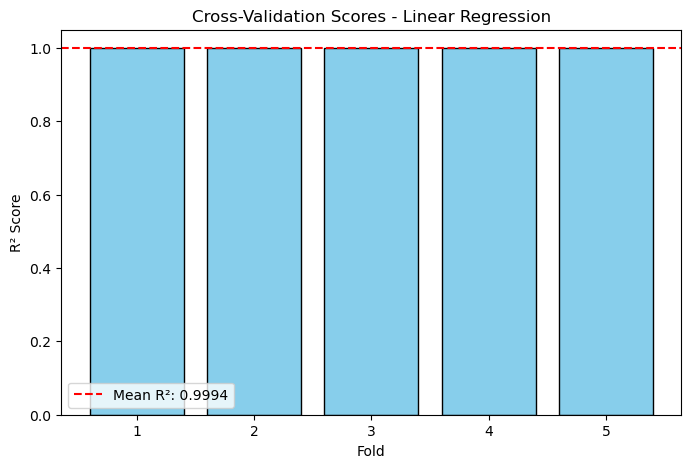

In [30]:
plt.figure(figsize=(8, 5))
plt.bar(range(1, cv_folds + 1), cv_scores, color='skyblue', edgecolor='black')
plt.axhline(y=mean_cv_score, color='red', linestyle='--', label=f"Mean R²: {mean_cv_score:.4f}")
plt.xlabel('Fold')
plt.ylabel('R² Score')
plt.title(f'Cross-Validation Scores - {best_model_name}')
plt.legend()
plt.show()


Model 2 80:20

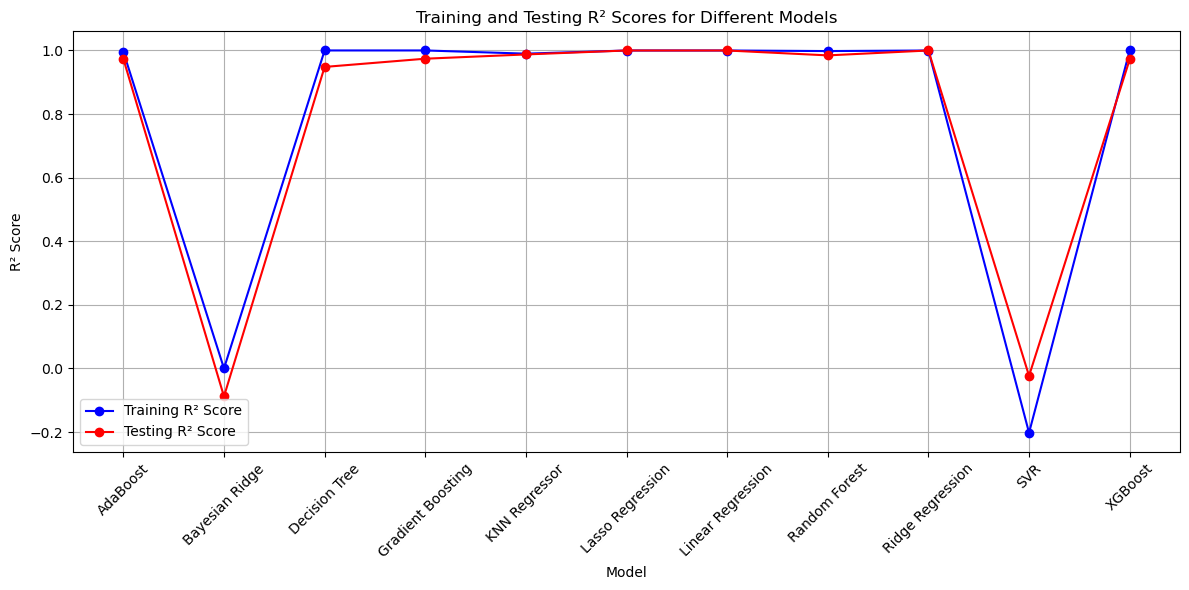

In [21]:
import matplotlib.pyplot as plt

# Extract model names and their corresponding R² scores
model_names = [r['Model'] for r in results2]
train_r2_scores = [r['Training R2 Score'] for r in results2]
test_r2_scores = [r['Testing R2 Score'] for r in results2]


# Set the figure size
plt.figure(figsize=(12, 6))

# Plot Training R² Scores
plt.plot(model_names, train_r2_scores, 'bo-', label='Training R² Score')

# Plot Testing R² Scores
plt.plot(model_names, test_r2_scores, 'ro-', label='Testing R² Score')

# Customize the plot
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.title('Training and Testing R² Scores for Different Models')
plt.xticks(rotation=45)  # Rotate model names for better visibility
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
